<a href="https://colab.research.google.com/github/Usermer/deep-learning-universe/blob/main/transfomers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import torch
from torch import nn

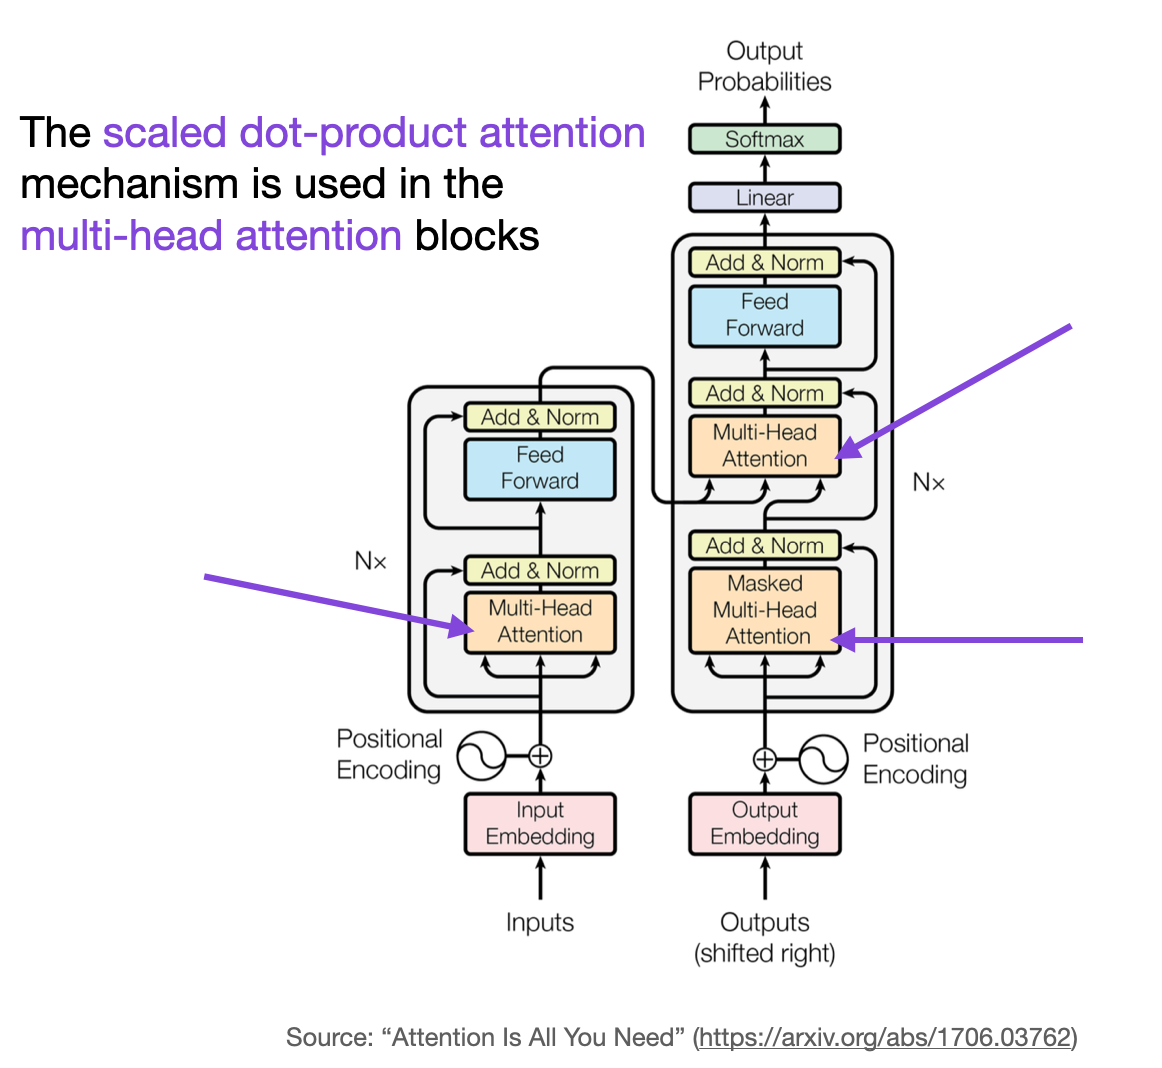

In [2]:
#etape1:input embedding

class InputEmbeddings(nn.Module):
  def __init__(self,d_model:int,vocab_size:int):
    super().__init__()
    self.d_model=d_model
    self.vocal_size=vocab_size
    self.embedding=nn.Embedding(vocab_size,d_model)

  def forward(self,x):
    return self.embedding(x)*math.sqrt(self.d_model)




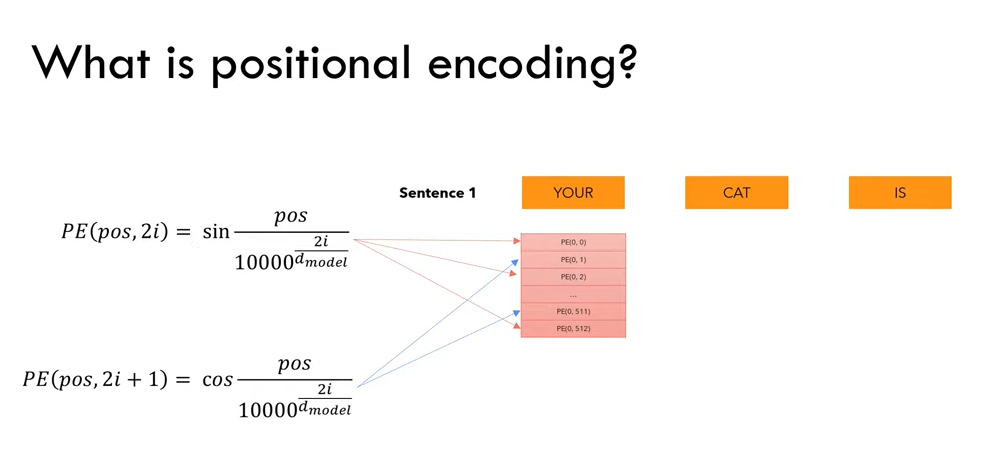

In [3]:
  #etape2:Positional ENCODING

  """
  methode1:appliquer les relation
  methode2:
  positional encoding appris
  -on cree une matrice de shape (vocab_size,d_model)
  -on apprend les valeurs pendant l'entrainement ,comme les embeddings des mots
  """
  class PositionalEncoding(nn.Module):
    def __init__(self,d_model:int,seq_len:int,dropout:float)->None:
      super().__init__()
      self.d_model=d_model
      self.seq_len=seq_len
      self.dropout=nn.Dropout(dropout)
      #creation de la matrice avec shape=(seq_len,d_model)
      pe=torch.zeros(seq_len,d_model)

      #create a vector pf shape(seq_len)
      position=torch.arange(0,seq_len,dtype=torch.float).unsqueeze(1)
      div_term=torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.0)/d_model))
      #apply the sin to even
      pe[:,0::2]=torch.sin(position*div_term)
      #apply the cos to odd
      pe[:,1::2]=torch.cos(position*div_term)

      pe=pe.unsqueeze(0)#(1,Seq_len_d_model)

      self.register_buffer('pe',pe)


    def forward(self,x):
      x=x+(self.pe[:,x.shape[1],:]).requires_grad(False)
      #pe est fixe et n'est pas entrainable
      return self.dropout(x)
